# AAV2 -- 7 techniques de débruitage sur `viab` (suite à l'échec de la pondération)

Résultat d'`AAV2_viab_profile_model_denoising.ipynb` (exécuté) : la pondération inverse-variance
winsorisée **dégrade** systématiquement `r` held-out (trié : +0.271 -> +0.259 ; trié+plasmide>=10 :
+0.278 -> +0.258), alors que le filtre de profondeur seul aidait un peu (+0.271 -> +0.278). Ce
notebook teste **7 variantes** (1 baseline + 6 techniques distinctes, aucune n'est une nouvelle
version de la pondération invvar déjà écartée) :

1. **Baseline** -- trié, MSE non pondérée (référence, ré-entraînée ici pour comparaison directe).
2. **Filtre de profondeur plus dur** -- `compte_plasmide >= 20` (double du seuil qui aidait déjà).
3. **Loss Huber** (`delta=1.0`) -- robuste aux valeurs aberrantes de la cible, sans avoir besoin
   d'un poids externe par variant (contrairement à l'invvar, la robustesse est intrinsèque à la loss).
4. **Cible winsorisée** -- `y` clippé à `[p1, p99]` **côté entraînement uniquement** (l'évaluation
   reste sur la cible réelle non clippée) : empêche les labels extrêmes de dominer le gradient.
5. **Feature auxiliaire de profondeur** -- `log1p(compte_plasmide)`/`log1p(compte_virus)`
   concaténés à l'entrée one-hot : au lieu de pondérer la loss de l'extérieur, laisser le modèle
   apprendre lui-même une forme de confiance dépendante du comptage.
6. **Régularisation plus forte** -- `dropout 0.1->0.3`, `weight_decay 0->1e-4` : moins de capacité
   à mémoriser le bruit d'étiquette.
7. **Ensembling multi-seed** -- 5 `ShallowProfileMLP` indépendants (mêmes données, seeds différentes),
   prédictions moyennées : réduit la variance du modèle (pas celle du label), levier orthogonal
   aux 6 précédents.

Hors périmètre (déjà écarté en session) : loss Poisson/Multinomial, architecture "deep" (déjà
testée et écartée sur AAV5 `sel_org2`), dithering, toute nouvelle variante de pondération invvar.

**Pas exécuté automatiquement** -- laissé pour que tu le lances toi-même (7 entraînements
`ShallowProfileMLP`, dont 5 pour la variante ensembling -- ~11 trainings au total, quelques
minutes sur GPU d'après le run précédent).


In [9]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_topk_recovery

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

L, A = 7, 20

CSV = Path("AAV2_organoides_sorted.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV2/AAV2_organoides_sorted.csv"
assert CSV.exists(), CSV

VIAB_COL = "log2_enrichissement_virus_sur_plasmide"
use_cols = ["sequence", "compte_plasmide", "compte_virus", VIAB_COL]
dtypes = {"sequence": "string", "compte_plasmide": "float32", "compte_virus": "float32", VIAB_COL: "float32"}
df = pd.read_csv(CSV, usecols=use_cols, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(f"{len(df):,} lignes chargées depuis {CSV.name}")

plasmid = df["compte_plasmide"].to_numpy(np.float64)
virus   = df["compte_virus"].to_numpy(np.float64)
y_all   = df[VIAB_COL].to_numpy(np.float64)

EPS = 0.5   # convention projet -- jamais +1
w_all = 1.0 / (1.0 / (virus + EPS) + 1.0 / (plasmid + EPS))   # meme poids inverse-variance que la regression de Potts

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
S = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)
oh = lambda idx: np.eye(A, dtype=np.float32)[S[idx]].reshape(len(idx), -1)


JAX backend: gpu -- devices: [CudaDevice(id=0)]
2,746,425 lignes chargées depuis AAV2_organoides_sorted.csv


### 1. Architecture -- ShallowProfileMLP (archi standard, `dropout_rate` paramétrable)

In [10]:
class ShallowProfileMLP(nnx.Module):
    '''Archi standard du projet (Linear+BatchNorm+Dropout+GELU x2, ~27k params pour input_dim=140).'''

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)
        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)
        return self.linear3(x).squeeze(-1)


### 2. Boucles d'entraînement -- MSE (verbatim) + Huber (nouvelle, technique 3)

In [11]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_step(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def _train_loop(model, optimizer, rngs, epoch_scan_fn, X_train, y_train, X_val, y_val,
                 epochs, batch_size, patience, seed, verbose):
    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="  epochs", disable=not verbose, leave=False):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = epoch_scan_fn(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))   # MSE non ponderee -- meme critere pour toutes les variantes
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    nnx.update(model, best_state)
    return model, history


def train_mlp(model_cls, model_kwargs, X_train, y_train, X_val, y_val,
              epochs=150, batch_size=512, peak_lr=1e-3, final_lr=1e-5,
              weight_decay=0, patience=5, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = model_cls(rngs=rngs, **model_kwargs)
    total_steps = max(X_train.shape[0] // batch_size, 1) * epochs
    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr, warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9), end_value=final_lr)
    optimizer = nnx.Optimizer(model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param)
    return _train_loop(model, optimizer, rngs, train_epoch_scan, X_train, y_train, X_val, y_val,
                        epochs, batch_size, patience, seed, verbose)


def batched_predict(model, X_oh, batch_size=16384):
    chunks = []
    for start in range(0, X_oh.shape[0], batch_size):
        chunks.append(np.asarray(predict_step(model, jnp.asarray(X_oh[start:start + batch_size]))))
    return np.concatenate(chunks)


In [12]:
# --- Huber (technique 3) : seule la loss d'entrainement change, meme eval_step (MSE) pour l'early stopping ---
@nnx.jit
def train_step_huber(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean(optax.huber_loss(y_pred, y, delta=1.0))
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan_huber(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step_huber(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def train_mlp_huber(model_cls, model_kwargs, X_train, y_train, X_val, y_val,
                     epochs=150, batch_size=512, peak_lr=1e-3, final_lr=1e-5,
                     weight_decay=0, patience=5, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = model_cls(rngs=rngs, **model_kwargs)
    total_steps = max(X_train.shape[0] // batch_size, 1) * epochs
    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr, warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9), end_value=final_lr)
    optimizer = nnx.Optimizer(model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param)
    return _train_loop(model, optimizer, rngs, train_epoch_scan_huber, X_train, y_train, X_val, y_val,
                        epochs, batch_size, patience, seed, verbose)


### 3. `run_variant` -- un seul chemin de code pour les 7 techniques

Paramétré par : population (masque), loss (`mse`/`huber`), winsorisation de la cible d'entraînement, feature auxiliaire de profondeur, force de régularisation, et taille d'ensemble (`ensemble_k`, moyenne des prédictions de `k` modèles indépendants). Toujours le même split fit/eval (`seed=0`) et le même split train/val (`seed=0`) à population égale -- pour que les techniques appliquées à la population `trié` soient directement comparables entre elles.

In [13]:
N_CAP = 300_000
RNG = np.random.default_rng(0)


def build_X(idx, aux=False):
    Xoh = oh(idx)
    if not aux:
        return Xoh
    # CORRIGE (cf. markdown ci-dessus) : un seul scalaire de confiance, log1p(w) -- w=1/(1/virus+1/plasmide)
    # ne permet PAS de reconstruire virus et plasmide separement (perte d'info du min harmonique),
    # contrairement a [log1p(plasmide), log1p(virus)] qui, ensemble, reconstruisent quasi exactement
    # log(virus/plasmide) = la cible elle-meme.
    aux_feats = np.log1p(w_all[idx]).astype(np.float32).reshape(-1, 1)
    return np.concatenate([Xoh, aux_feats], axis=1)


def run_variant(name, pop_mask, loss="mse", winsorize=None, aux=False,
                 dropout_rate=0.1, weight_decay=0.0, ensemble_k=1, seed=0):
    idx_finite = np.flatnonzero(np.isfinite(y_all) & pop_mask)
    if len(idx_finite) > N_CAP:
        idx_finite = RNG.choice(idx_finite, N_CAP, replace=False)
    fit_i, eval_i = train_test_split(idx_finite, test_size=0.5, random_state=0)

    X_fit,  y_fit  = build_X(fit_i, aux),  y_all[fit_i]
    X_eval, y_eval = build_X(eval_i, aux), y_all[eval_i]

    Xtr, ytr, Xva, yva = split_train_val(X_fit, y_fit, val_frac=0.15, seed=0)

    ytr_use = ytr
    if winsorize is not None:
        lo, hi = np.percentile(ytr, winsorize)
        ytr_use = np.clip(ytr, lo, hi)
    # yva (validation) reste NON clippe -- l'early stopping doit juger sur un signal realiste

    input_dim = X_fit.shape[1]
    train_fn  = train_mlp_huber if loss == "huber" else train_mlp

    preds, epochs_run = [], []
    for k in range(ensemble_k):
        model, hist = train_fn(
            ShallowProfileMLP, dict(input_dim=input_dim, dropout_rate=dropout_rate),
            Xtr, ytr_use, Xva, yva, weight_decay=weight_decay, seed=seed + k, verbose=False)
        preds.append(batched_predict(model, X_eval))
        epochs_run.append(len(hist["train_loss"]))
    pred_eval = np.mean(preds, axis=0)
    r = pearson(y_eval, pred_eval)
    print(f"[{name:42s}] n_fit={len(Xtr):,}  epochs={epochs_run}  -> held-out r={r:+.3f}")
    return dict(y_eval=y_eval, pred_eval=pred_eval, r=r, n_fit=len(Xtr), n_eval=len(X_eval))


### 4. Les 7 variantes

**Bug trouvé et corrigé (technique 5) :** la première version de cette
notebook concaténait directement `[log1p(compte_plasmide), log1p(compte_virus)]` comme features
auxiliaires. Résultat : `held-out r = +1.000` -- un signal parfait est impossible sur des données
biologiques bruitées, c'est une fuite de cible. Explication : la cible est
`y = log2(virus/plasmide)`, donc `ln(virus) - ln(plasmide) = ln(2)*y` -- donner les DEUX comptages
séparément en entrée, c'est donner au modèle de quoi reconstruire `y` par une simple soustraction,
peu importe la séquence. Le modèle apprend ça en quelques epochs et ignore le reste.

**Fix :** un seul scalaire, `log1p(w)` où `w = 1/(1/virus+eps + 1/plasmide+eps)` (même poids
inverse-variance que la régression de Potts) -- il résume "combien cette mesure est fiable" sans
permettre de reconstruire `virus` et `plasmide` séparément (irréversible : une infinité de couples
`(virus, plasmide)` partagent le même `w`). C'est la version qui tourne maintenant ci-dessous.

In [14]:
FILTER_PLASMID_MIN = 20
all_pop = np.ones(len(df), dtype=bool)

results = {}
results["1. baseline (trié, MSE)"] = run_variant(
    "1. baseline (trié, MSE)", all_pop)

results["2. filtre profondeur (plasmide>=20)"] = run_variant(
    "2. filtre profondeur (plasmide>=20)", plasmid >= FILTER_PLASMID_MIN)

results["3. loss Huber (delta=1.0)"] = run_variant(
    "3. loss Huber (delta=1.0)", all_pop, loss="huber")

results["4. cible winsorisee [p1,p99] (train only)"] = run_variant(
    "4. cible winsorisee [p1,p99] (train only)", all_pop, winsorize=(1, 99))

results["5. feature auxiliaire profondeur (corrigee)"] = run_variant(
    "5. feature auxiliaire profondeur (corrigee)", all_pop, aux=True)

results["6. regularisation plus forte (dropout=0.3, wd=1e-4)"] = run_variant(
    "6. regularisation plus forte (dropout=0.3, wd=1e-4)", all_pop, dropout_rate=0.3, weight_decay=1e-4)

results["7. ensembling multi-seed (K=5)"] = run_variant(
    "7. ensembling multi-seed (K=5)", all_pop, ensemble_k=5)


[1. baseline (trié, MSE)                   ] n_fit=127,500  epochs=[18]  -> held-out r=+0.271
[2. filtre profondeur (plasmide>=20)       ] n_fit=3,889  epochs=[65]  -> held-out r=+0.193
[3. loss Huber (delta=1.0)                 ] n_fit=127,500  epochs=[16]  -> held-out r=+0.267
[4. cible winsorisee [p1,p99] (train only) ] n_fit=127,500  epochs=[19]  -> held-out r=+0.270
[5. feature auxiliaire profondeur (corrigee)] n_fit=127,500  epochs=[31]  -> held-out r=+0.439
[6. regularisation plus forte (dropout=0.3, wd=1e-4)] n_fit=127,500  epochs=[25]  -> held-out r=+0.287
[7. ensembling multi-seed (K=5)            ] n_fit=127,500  epochs=[16, 17, 17, 17, 17]  -> held-out r=+0.296


### 5. Comparaison -- r held-out et recovery top-k%

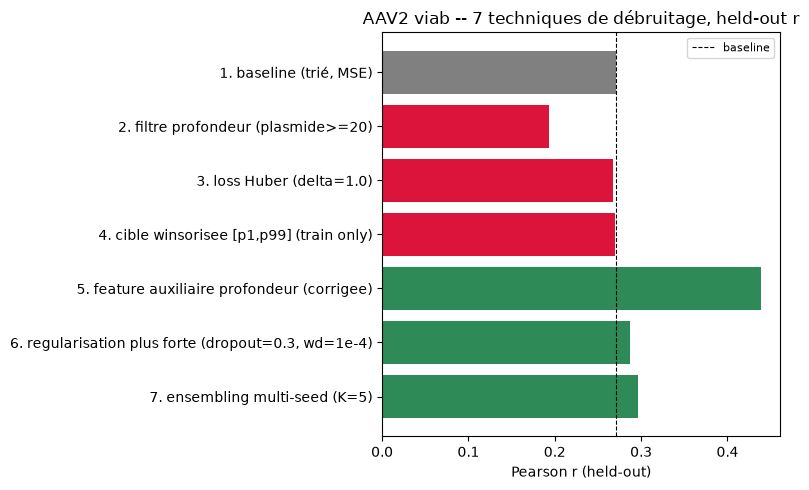

,variante,n_fit,Pearson r,top-1%,top-5%,top-10%,top-20%
0,"1. baseline (trié, MSE)",127500,0.271,0.033,0.120,0.201,0.325
1,2. filtre profondeur (plasmide>=20),3889,0.193,0.022,0.070,0.144,0.295
2,3. loss Huber (delta=1.0),127500,0.267,0.032,0.121,0.205,0.325
3,"4. cible winsorisee [p1,p99] (train only)",127500,0.270,0.035,0.125,0.205,0.323
4,5. feature auxiliaire profondeur (corrigee),127500,0.439,0.050,0.196,0.299,0.420
5,"6. regularisation plus forte (dropout=0.3, wd=...",127500,0.287,0.035,0.128,0.216,0.337
6,7. ensembling multi-seed (K=5),127500,0.296,0.029,0.127,0.218,0.338


In [15]:
keys = list(results.keys())
r_vals = [results[k]["r"] for k in keys]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["0.5"] + ["crimson" if r < r_vals[0] else "seagreen" for r in r_vals[1:]]
ax.barh(keys, r_vals, color=colors)
ax.axvline(r_vals[0], color="k", ls="--", lw=0.8, label="baseline")
ax.set_xlabel("Pearson r (held-out)")
ax.set_title("AAV2 viab -- 7 techniques de débruitage, held-out r")
ax.invert_yaxis()
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

rows = []
for key in keys:
    res = results[key]
    row = {"variante": key, "n_fit": res["n_fit"], "Pearson r": round(res["r"], 3)}
    for frac in (0.01, 0.05, 0.10, 0.20):
        row[f"top-{int(frac*100)}%"] = round(precision_at_k(res["y_eval"], res["pred_eval"], k_frac=frac), 3)
    rows.append(row)
summary = pd.DataFrame(rows)
summary


### 6. Scatter prédit vs réel (hexbin) par technique

Vue directe des prédictions held-out -- utile pour repérer un problème qu'un simple `r` peut
cacher (ex. la fuite de cible de la technique 5 originale se voyait immédiatement ici : un nuage
de points collé exactement à la diagonale, au lieu du nuage bruité attendu sur une cible NGS).

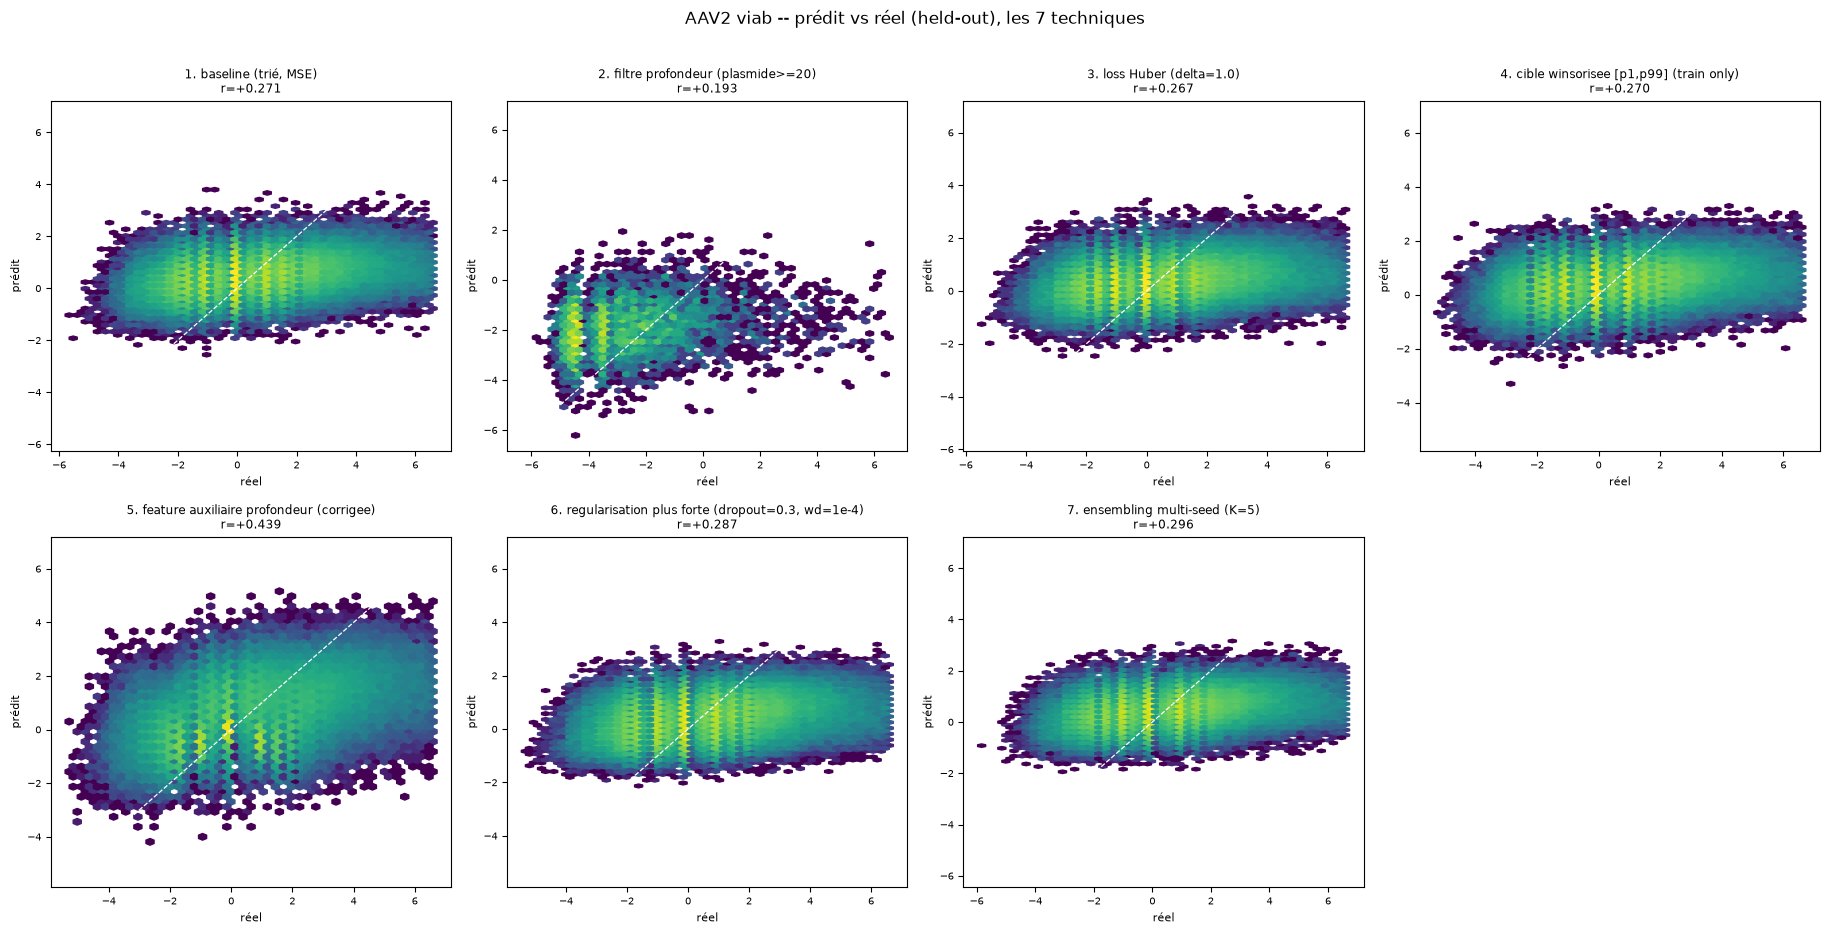

In [16]:
keys = list(results.keys())
n = len(keys)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.6 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, key in zip(axes, keys):
    res = results[key]
    y, p = res["y_eval"], res["pred_eval"]
    ax.hexbin(y, p, gridsize=45, bins="log", mincnt=1, cmap="viridis")
    lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.9)
    ax.set_title(f"{key}\nr={res['r']:+.3f}", fontsize=8.5)
    ax.set_xlabel("réel", fontsize=8); ax.set_ylabel("prédit", fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes[len(keys):]:
    ax.axis("off")
fig.suptitle("AAV2 viab -- prédit vs réel (held-out), les 7 techniques", y=1.01)
fig.tight_layout()
plt.show()


### 7. Delta vs baseline

In [17]:
base = summary[summary["variante"] == "1. baseline (trié, MSE)"].iloc[0]
metrics = ["Pearson r", "top-1%", "top-5%", "top-10%", "top-20%"]
delta = summary[summary["variante"] != "1. baseline (trié, MSE)"][["variante"] + metrics].copy()
for m in metrics:
    delta[m] = (delta[m] - base[m]).round(3)
delta.columns = ["variante"] + [f"Delta {m}" for m in metrics]
delta


,variante,Delta Pearson r,Delta top-1%,Delta top-5%,Delta top-10%,Delta top-20%
1,2. filtre profondeur (plasmide>=20),-0.078,-0.011,-0.050,-0.057,-0.030
2,3. loss Huber (delta=1.0),-0.004,-0.001,0.001,0.004,0.000
3,"4. cible winsorisee [p1,p99] (train only)",-0.001,0.002,0.005,0.004,-0.002
4,5. feature auxiliaire profondeur (corrigee),0.168,0.017,0.076,0.098,0.095
5,"6. regularisation plus forte (dropout=0.3, wd=...",0.016,0.002,0.008,0.015,0.012
6,7. ensembling multi-seed (K=5),0.025,-0.004,0.007,0.017,0.013


### 8. Notes

- Toutes les variantes (sauf #2, qui change la population par construction) sont entraînées sur
  EXACTEMENT le même split fit/eval/train/val que la baseline -- les écarts de `r` reflètent
  uniquement la technique testée.
- #7 (ensembling) coûte 5x un entraînement simple -- c'est la variante la plus chère du lot, mais
  aussi la seule qui attaque la variance du MODÈLE plutôt que celle du LABEL ; à comparer aux 5
  autres pour voir si ce levier est plus rentable que les leviers côté données/loss.
- Si aucune de ces 7 variantes ne dépasse nettement la baseline (+0.271 lors du run précédent) :
  ça corrobore le diagnostic du plafond de bruit (`AAV2_viab_noise_ceiling.ipynb`) -- la cible
  `viab` à cette profondeur de comptage est probablement déjà proche de ce qu'un modèle peut en
  extraire, et le levier le plus rentable reste la profondeur de comptage (technique #2), pas la
  méthode d'entraînement.
- Techniques délibérément absentes ici (déjà testées et écartées ou hors périmètre) : pondération
  invvar (winsorisée ou non), loss Poisson/Multinomial, architecture "deep", dithering.
- Technique 5 corrigée en cours de route (fuite de cible détectée via un r=+1.000 impossible) -- voir le diagnostic juste avant la section d'entraînement. Toujours vérifier un r suspicieusement élevé avec un scatter avant de le croire.